# Generate data by running Basener's script

Here we run an excerpt of the JavaScript embedded in William Basener's [Realistic Mutation-Selection Modeling](https://people.rit.edu/wfbsma/evolutionary%20dynamics/EvolutionaryModel.html) webpage, and generate the data that Basener and Sanford report upon in Section 5.

**What Basener and Sanford actually did to generate their data is quite different from what they indicate in the article.**

1. Basener and Sanford did not, as they claim in the introduction to Section 5, hold essential parameters constant. The lower limit of the interval of fitnesses, and also the spacing of points within the interval, vary from one case to the next.

2. Basener and Sanford did not run their "simulation" with no mutations, as claimed in Sections 5.1 and 5.2 of the article, but instead calculated the value of a simple formula.

3. Basener's script does not set the standard deviation of the Gaussian distribution of mutation effects as Basener and Sanford claim in Section 5.3.

**The figures in the article are inconsistent with one another, as are the figures on Basener's webpage.**

In the Gamma case (Section 5.4), two of the line plots show the mean fitness decreasing to -0.014 in year 2500 (this is the value that Basener and Sanford report in the text), while the "Population Distribution" plot shows that the mean fitness decreases to -0.017. The same inconsistency appears at the webpage, with the "Population Distribution" plot indicating in text that the mean fitness reaches -0.017. Inspecting the data, we find that -0.017 is the correct value.


## Determining how B&S subdivided the fitness interval

The interval of Malthusian growth factors (fitnesses) is not user-adjustable, but it varies in the figures of the article. Thus it appears that Basener and Sanford ran different versions of the code in different cases. We'll work with the hard-coded interval $[-0.1,\, 0.15],$ and set the "number of discrete population fitness values" parameter of Basener's webpage to obtain matches to the figures in the article. 
 
Basener and Sanford claim that the initial frequency distribution is a discretized normal distribution $\mathcal{N}(0.044,\, 0.005)$ in all cases. It appears that this is true, and we proceed under the assumption that it is in fact true. This allows us to transform the maximum of the initial frequencies, obtained by eyeballing a figure in the article, into an estimate of the number of subintervals in the partition of the interval of growth factors.

We begin by inspecting the relevant passage in Basener's code. First the probabilty *density* `P` is calculated at all growth factors `m[i]`, excepting those that differ from the mean by more than 11.2 standard deviations.


```javascript
var mean = 0.044;
var stdev = 0.005;
var fitnessRange = [-0.1, 0.15];
var numStDev = 11.2;
// snip
var minFitness = mean - numStDev * stdev;
var maxFitness = mean + numStDev * stdev;


GaussianMultiplicativeTerm = 1 / (stdev * Math.sqrt(2 * Math.PI));
// Correct error: last iteration assigns to memory out of bounds
for (i = 0; i < numIncrements /* + 1 */; i++) { 
    P[i] = GaussianMultiplicativeTerm * Math.exp(-0.5 * Math.pow((m[i] - mean) / stdev, 2));
    if (m[i] < minFitness) {
        P[i] = 0
    };
    if (m[i] > maxFitness) {
        P[i] = 0
    };
}
```

The result of (inaccurately) normalizing the array `P` of probability densities is assigned to the initial frequency distribution `Psolution[0]`.

```javascript   
s = 0;
for (i = 0; i < numIncrements; i++) {
    s = s + P[i]
}

var maxPinitial = 0;
for (var i = 0; i < numIncrements; i++) {
    Psolution[0][i] = P[i] / s;
    PsolutionForPlot[0][i] = P[i] / s;
    maxPinitial = Math.max(maxPinitial, PsolutionForPlot[0][i]);
}
```

Note that it is not the array `P`, but instead the array `Psolution`, that corresponds to $P$ in the article. `P` is merely a temporary variable. It is used only in calculating the initial frequency distribuiton `Psolution[0]`. The array `PsolutionForPlot`, which is used in generating the figures that we inspect, stores the normalized frequency distributions. **In the Python code of this binder, the variable `P` corresponds to $P$ in the article, and to `Psolution` in Basener's script.**

Our first objective, in responding to each of the subsections of Section 5, is to determine the value of `numIncrements`, set according to the "number of discrete population fitness values" input on Basener's webpage, from the value of `maxPinitial`, which we estimate by looking at a figure in the article. We will verify that the following function produces the correct result.

In [2]:
%matplotlib notebook
%run ../Code/bs.py

distribution = stats.norm(0.044, 0.005)

def n_fitnesses(max_initial_frequency):
    density_at_mean = distribution.pdf(distribution.mean())
    delta = max_initial_frequency / density_at_mean
    return round((0.15 - -0.1) / delta)

## Section 5.2: No mutations

In this case, the conditions under which Basener and Sanford generated their data are radically different from those that they report. Let's begin with the easy determination. The frequency of the mean fitness in [Figure 2](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig2_HTML.gif) is about 0.032, and thus the approximate number of fitnesses is:

In [403]:
n_fitnesses(0.032)

623.0

The fitness interval in Figure 2 is 25 percent shorter than the interval for the current version of Basener's code. So we gather that Basener and Sanford set the "number of discrete population fitness values" to 500 for the shorter interval, and that we should set the parameter to 625 for the longer interval.


Now we move to the difficult part. In Section 5.2, Basener and Sanford claim to "present a simulation," having explained:

>To remain biologically realistic, we assume a finite population: any subpopulation $P_i$  that contains less than some fraction of the population is assumed to contain zero organisms. For the numerical simulations, we set \[the frequency\] $P_i=0$  whenever $P_i$  is less than $10^{-9}$  of the total population.

In concrete terms, Basener and Sanford claim that they always select the "Finite" option on Basener's webpage. However, what the code actually does is to scale the threshold $10^{-9}$ by the maximum of the frequencies, not by their sum. Here is the relevant passage in Basener's JavaScript:

```javascript
if (PopSize == "Finite") {
    maximumP = Math.max.apply(Math, Psolution[t]);
    for (i = 0; i < numIncrements; i++) {
        Psolution[t][i] = Psolution[t][i] * (Psolution[t][i] > maximumP * 0.000000001);
    }
}
```

In the absence of mutation, when a frequency is set to zero, it remains zero forevermore. At the beginning of a run, the maximum fitness with a frequency above threshold is 0.076. 

In [3]:
n = 625
fitnesses = np.linspace(-0.1, 0.15, n + 1)
bin_width = (fitnesses[-1] - fitnesses[0]) / n
frequencies = distribution.pdf(fitnesses) * bin_width
frequencies /= fsum(frequencies)
threshold = 1e-9 * np.max(frequencies)
np.max(fitnesses[frequencies >= threshold])

0.07600000000000001

Running the code at the webpage for 3500 years, with the options "Finite" and "None (selection, no mutation)," you will see that the maximum fitness with nonzero frequency is indeed 0.076. However, the maximum in  [Figure 4](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif) of the article is about 0.10. **Thus it cannot be the case that Basener and Sanford made the population "finite" as they claim.** Simply switching to the "Infinite" option does not give a match of Figure 4. Basener and Sanford did not generate their data with the setting "None (selection, no mutation),"  referred to as `None` within the code. They instead generated it with the setting "None using exact solution exponential formula," referred to as `NoneExact` within the code. 

Obviously, use of a formula to calculate an exact solution is not a simulation. But that is what makes Basener's webpage generate results matching those in the article. With the "number of discrete population fitness values" set to 625, the depiction of the initial distribution on the webpage is a good match for that in the article. Furthermore, with "mutation distribution type" of `NoneExact` ("None using exact solution exponential formula"), the mean fitness is 0.05 after 250 years, as stated explicitly in [Figure 2](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig2_HTML.gif), and is 0.063 after 750 years, as stated explicitly in [Figure 4](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif). Furthermore, the final distribution matches that of Figure 4, and the final distributions obtained with parameter settings of 600 and 650 (instead of 625) do not match that of Figure 4.

We will delve into the difference between the `None` and `NoneExact` options, which turns out to be important, in [Replication of Section 5.2 (No Mutations)](2_No_Mutations.ipynb). Thus we use Basener's code to generate data for both.

### Mutation type `NoneExact`

In the next cell, we generate a command line `c` to run the script, and then submit it to the command line interpreter (shell) of the host computer. Then we load the JSON output of the script, convert it to a Python dictionary, and dump the pickled dictionary to a gzipped file.

In [4]:
%%time
case = 'NoneExact'
n = 625
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Infinite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_2desired.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_2desired')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_2desired.json
Done.
CPU times: user 5.97 s, sys: 806 ms, total: 6.77 s
Wall time: 1min 7s


Now we load the data, and verify that the maximum of the intial frequencies is about 0.032, as we see in Figure 2 of the article.

In [5]:
with gzip.open('../Basener_Sanford_Data/bs5_2desired.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.03191538243211459

Next we plot the data that we have just loaded, and obtain a good match for the corresponding figure in the article.

In [7]:
# %load ../Code/bs_plot.py
def bs_plot(frequencies, m, intermediate):
    fig, ax = plt.subplots()
    ax.set_xlabel('Malthusian Growth Factor (Fitness)')
    ax.set_ylabel('Proportion')
    years = [0, intermediate, len(frequencies) - 1]
    colors = ['r', 'b', 'limegreen']
    for year, color in zip(years, colors):
        p = frequencies[year] / fsum(frequencies[year])
        mean = fsum(p * m)
        label = 'Year {0} (mean {1:.3f})'.format(year, mean)
        ax.plot(m[p>0], p[p>0], color=color, label=label)
    ax.legend(loc='upper left')
    return fig, ax

<IPython.core.display.Javascript object>


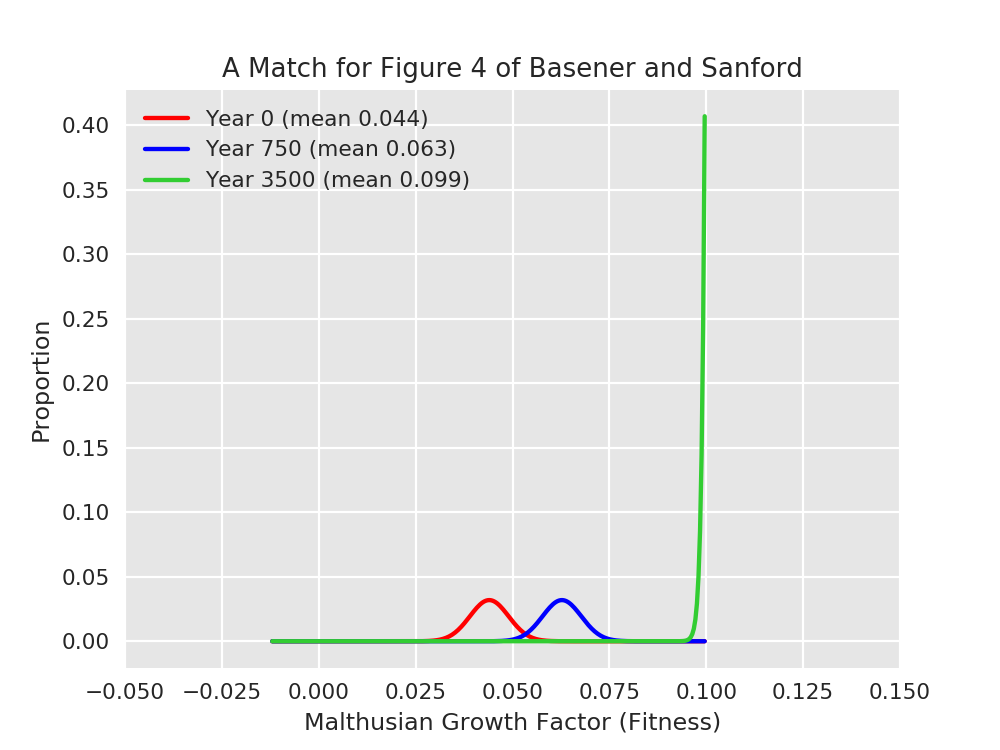

In [8]:
fig, ax = bs_plot(data['Psolution'], data['m'], 750)
ax.set_title('A Match for Figure 4 of Basener and Sanford')
ax.set_xlim(-0.05, 0.15)
save_ylim = ax.get_ylim()

**Figure 4 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" /></a>


Click on the image for full resolution.

We also establish that we can redo the formulaic calculation using the data that Basener's code operated upon. Note that `np.outer(t, m)` produces the outer product of the vectors `t` of times (years) and `m` of Malthusian growth factors of the types of organism.

In [621]:
m = data['m']
t = np.arange(data['numYears'])
P0 = data['Psolution'][0]
P = P0 * np.exp(np.outer(t, m))
maximum_absolute_relative_error(P, data['Psolution'])

4.440892098500626e-16

Assuming that there is no loss of precision in the JSON output of `BS.js` (there is not supposed to be), then we are seeing the effects of slight differences in implementation of the exponential function. There's nothing at all surprising or worrisome about such a tiny discrepancy. Note that the significands of the numbers are 53 bits in length, and that the value of $2^{-53}$ is:

In [622]:
2 ** -53

1.1102230246251565e-16

There is, however, an inaccuracy in Basener's calculation that we will can correct. As shown in the following cell, an accurate sum of his initial frequency distribution gives a result less than 1. Furthermore, the error is accounted for perfectly as the ratio of the accurate (`fsum`) and inaccurate (`sum`) sums of the unnormalized frequency distribution.

In [623]:
fsum(data['Psolution'][0]), fsum(data['P']) / sum(data['P'])

(0.9999999999999992, 0.9999999999999992)

Now we do the same calculation, operating on data generated by my Python code. First we calculate the growth factors and closely related quantities, and verify that the results are exactly equal to the corresponding quantities calculated by Basener's code.

In [624]:
factors = Factors(625, exclude_max=True)
assert np.array_equal(factors.growth, data['m'])
assert np.array_equal(factors.birth, data['b'])
assert factors.delta == data['mDelta']

In [642]:
# %load ../Code/bs_init.py
def bs_init(growth_factors, mean=0.044, std=0.005, z_limit=11.2, norm=1):
    """
    Returns a discretized Gaussian distribution over growth factors.

    Growth factors differing from the given `mean` by more than `z_limit`
    standard deviations are assigned probability zero. Each of the other
    growth factors m has probability proportional to f(m), where f is the
    probability density function of the distribution N(mean, std). The
    resulting distribution is scale to have the given `norm`.
    """
    z = (growth_factors - mean) / std
    frequencies = np.where(np.abs(z) > z_limit, 0, np.exp(-0.5 * z**2))
    return norm * frequencies / fsum(frequencies)

In [669]:
m = factors.growth
t = np.arange(N_YEARS['NoneExact'] + 1)
P0 = bs_init(m)
P = P0 * np.exp(np.outer(t, m))
np.max(relative_error(P, data['Psolution'], absolute=True)[:, P0 > 0])

1.3322676295501878e-15

In [670]:
# %load ../Code/plot_errors.py
def plot_errors(P, data, title):
    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Relative Error')
    e = [np.max(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data)]
    ax.plot(e, label='max absolute')
    e = [np.mean(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data)]
    ax.plot(e, label='mean absolute')
    e = [np.mean(relative_error(p[d>0], d[d>0], absolute=False)) for p, d in zip(P, data)]
    ax.plot(e, label='mean signed')
    ax.legend(loc='upper left')
    return fig, ax

<IPython.core.display.Javascript object>


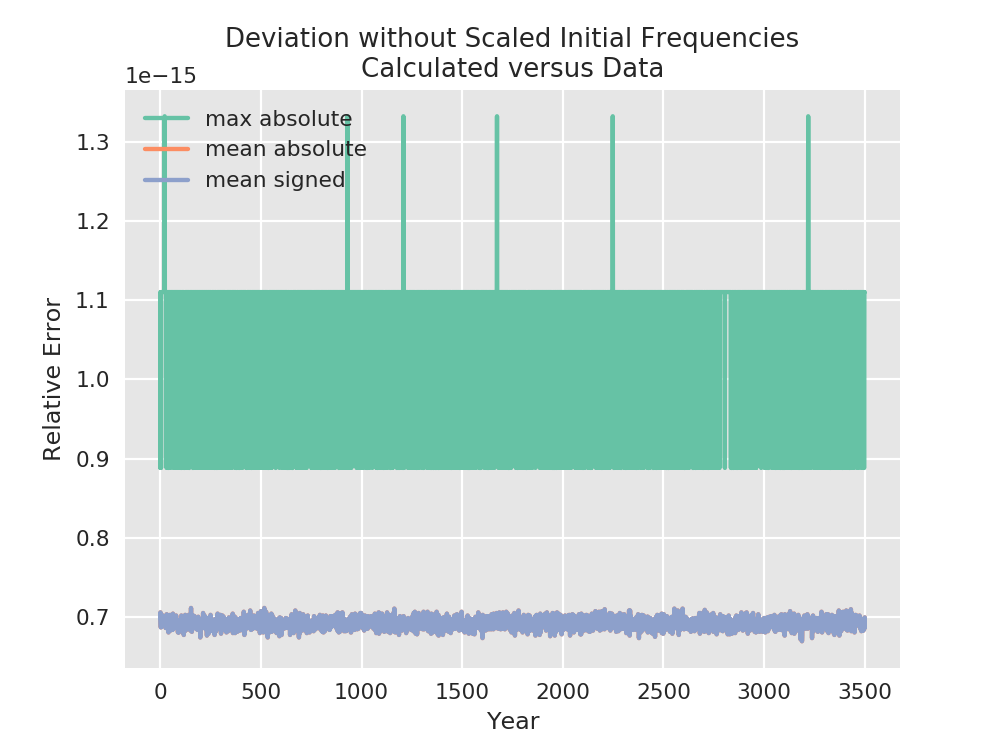

In [671]:
title = 'Deviation without Scaled Initial Frequencies\nCalculated versus Data'
plot_errors(P, data['Psolution'], title);

Now we scale `P0` to match `Psolution[0]` in norm, and obtain a considerable reduction in the mean of the absolute relative error (with the calculation restricted to nonzero frequencies).

In [674]:
P0 = bs_init(factors.growth, norm=fsum(data['Psolution'][0]))

########
P0 = data['Psolution'][0]
########

P = P0 * np.exp(np.outer(t, factors.growth))
np.max(relative_error(P, data['Psolution'], absolute=True)[:, P0 > 0])

4.440892098500626e-16

<IPython.core.display.Javascript object>


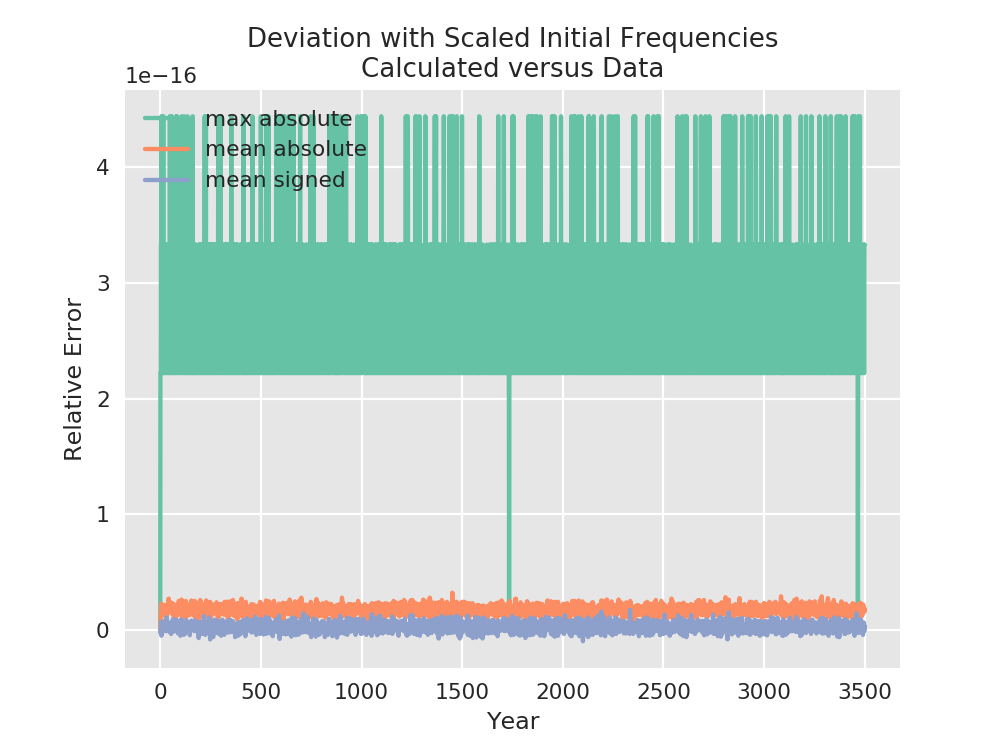

In [675]:
title = 'Deviation with Scaled Initial Frequencies\nCalculated versus Data'
plot_errors(P, data['Psolution'], title);

Matching the initial frequencies is more important in other cases, i.e., with iterated updates of frequencies, than in this one.

### Mutation type `None`

Now we do the same, but for the "mutation distribution type" `None` instead of `NoneExact`. 

In [361]:
%%time
case = 'None'
n = 625
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Infinite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_2actual.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_2actual')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_2actual.json
Done.
CPU times: user 6.13 s, sys: 839 ms, total: 6.97 s
Wall time: 1min 5s


The maximum of the initial frequencies should be exactly the same in this case as in the `NoneExact` case.

In [576]:
with gzip.open('../Basener_Sanford_Data/bs5_2actual.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.03191538243211459

The crucial feature to note in the following plot is the maximum proportion in year 3500. I've set the the limits on the y-axis as in the preceding figure, to make it plain that the maximum is much less than in Figure 4 of the article.

<IPython.core.display.Javascript object>


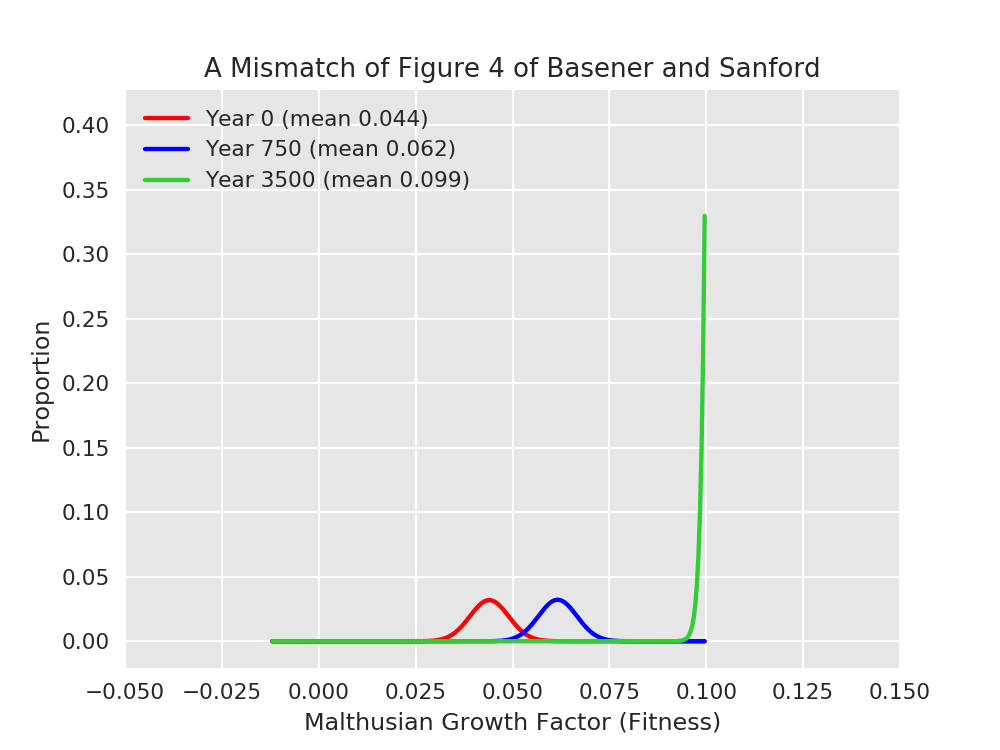

In [350]:
fig, ax = bs_plot(data['Psolution'], data['m'], 750)
ax.set_title('A Mismatch of Figure 4 of Basener and Sanford')
ax.set_xlim(-0.05, 0.15)
ax.set_ylim(save_ylim);

**Figure 4 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" /></a>


Click on the image for full resolution.

In [577]:
factors = Factors(625, exclude_max=True)
assert np.array_equal(factors.growth, data['m'])
assert np.array_equal(factors.birth, data['b'])
assert factors.delta == data['mDelta']

Now we reimplement the annual update of frequencies, and include a simple extension. When `updates_per_year` is set greater than 1, the function does multiple iterations, with the birth factors and the death factor reduced proportionately.

In [578]:
# %load ../Code/bs_annual_update.py
def bs_annual_update(factors, frequencies, mutations,
                     threshold_norm=None, updates_per_year=1):
    birth_factors = factors.birth / updates_per_year
    death_factor = factors.death / updates_per_year
    f = np.array(frequencies)
    births = np.empty_like(f)
    for _ in range(updates_per_year):
        births[:] = np.convolve(birth_factors * f, mutations, mode='valid')
        f *= (1 - death_factor)
        f += births
    if not threshold_norm is None:
        f[f <= 1e-9 * threshold_norm(f)] = 0
    return f

We check to see whether our reimplementation of the annual update rule works as Basener's does in the case of no mutations.

In [579]:
t = np.arange(N_YEARS['None'] + 1)
P = np.empty((len(t), len(factors.growth)))
P[0] = bs_init(factors.growth, norm=fsum(data['Psolution'][0]))
np.mean(relative_error(P[0], data['Psolution'][0], absolute=True)[P0>0])

5.2580162446247416e-17

In [580]:
no_mutation = np.zeros_like(factors.effects)
no_mutation[len(no_mutation) // 2] = 1
assert np.array_equal(no_mutation, no_mutation[::-1])
for year in t[1:]:
    P[year] = bs_annual_update(factors, P[year-1], no_mutation, updates_per_year=1)
np.mean(relative_error(P, data['Psolution'], absolute=True))

1.9589958472562303e-14

In [676]:
plt.close('all')
title = '\nCalculated versus Data'
fig, ax = plot_errors(P, data['Psolution'])
ax.set_title('Errors of Results Relative to B&S Data');

TypeError: plot_errors() missing 1 required positional argument: 'title'

**Basener and Sanford do not report in that they bias the results in favor of a "crashing population" by**

3. setting the probability that mutation has no effect on fitness to the (much smaller) probability that mutation has a minimally deleterious effect,
2. setting the fraction of mutations with beneficial effects 40 percent lower than claimed, 
9. making the effective birth rates $b^\prime_j = \sum_i f_{ij}b_j \leq 0.82 b_j,$ \[put all of population on growth rate 0, and do one update\]
1. setting the numbers $f_{ij}b_j P_j$ of births to zero when they are small in relation to the current population, and
0. \[using large time steps\].

Given that the third item is a blatant hack of the code, not something that Basener did and that the results depend Supposing that Basener is an egregiously incompetent programmer, we may allow that the first two biases might be due to programming. However, the third is the consequence of a blatant hack in the `Gamma` case. 

The plot indicates that our implementation of the annual update rule always produces greater frequencies than does Basener's implementation. We shouldn't be accumulating a 2-digit discrepancy in such a simple calculation, i.e., without mutation. Investigating, we find that **Basener takes an approach that reduces the impact of positive mutations on the results.** Whether or not he does so purposefully, he certainly does serve his purposes. Our detection of bias in the absence of mutation serves to underscore the atrociousness of his method for registering births. In the nested `for` loop of the following code segment, you will see that, rather than sum the numbers of births of type `i`, as indicated in Equation **???** of Basener and Sanford, Basener adds the numbers of births, one by one, to the current number of organisms of type `i`. Some of the numbers of births are very small in relation to the current number of organisms, and are consequently rounded to 0 in the summation. That is why Basener's updates of frequencies always produce frequencies that are smaller than our own.

```javascript
for (i = 0; i < numIncrements; i++) {

    // Never initialize an accumulator with a number much larger than
    // the remaining summands, as Basener does here:
    Psolution[t][i] = Psolution[t - 1][i];

    for (j = 0; j < numIncrements; j++) {
        // Relatively small addends (numbers of births) are rounded to 0.
        Psolution[t][i] = Psolution[t][i] + Psolution[t - 1][j] * MP[i][j];
    }

    Psolution[t][i] = Psolution[t][i] - deathRate * Psolution[t - 1][i];

    // Override iteration results with formulaic calculation.
    if (mt == "NoneExact") 
        Psolution[t][i] = Psolution[0][i] * Math.exp(t * m[i]);

    // snip
}
```

It is conceivable that Basener, a mathematician, is an incompetent programmer. However, we will see that he has elsewhere rigged his code brazenly. 

```javascript
for (i = 0; i < numIncrements; i++) {
    var births = jStat.dot(Psolution[t-1], MP[i]);
    Psolution[t][i] = births + (1 - deathRate) * Psolution[t - 1][i];

    if (mt == "NoneExact") 
        Psolution[t][i] = Psolution[0][i] * Math.exp(t * m[i]);
    s = s + Psolution[t][i];
}
```

The problem is needless imprecision in Basener's (oddly structured) calculation. I have copied [`BS.js`](../Code/BS.js) to [`BSalt.js`](../Code/BSalt.js), imported the `jStat` statistical package (which happens to provide a function to calculate the dot product of vectors), and introduced a bit of sanity:

If the error is honest, then Basener is incompetent to produce software for numerical studies. Note that we have eliminated, by way of simplification, a number of unnecessary indexing operations in the region of code that dominates execution time. Now we run `BSalt.js`, and again check the mean value of the absolute relative error.

In [360]:
%%time
case = 'None'
n = 625
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Infinite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BSalt.js',
               output_path='../Basener_Sanford_Data/bs5_2alt.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_2alt')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_2alt.json
Done.
CPU times: user 3.81 s, sys: 386 ms, total: 4.2 s
Wall time: 19.9 s


**We have reduced the running time to less than a third of what is was previously&hellip;**

In [590]:
with gzip.open('../Basener_Sanford_Data/bs5_2alt.pickled.gz') as f:
    data = pickle.load(f)
np.mean(relative_error(P, data['Psolution'], absolute=True)[:, P[0]>0])

5.1359989877197166e-17

**&hellip; and have also increased the precision considerably.**

Both the speed and the precision are important, The result of iterating the annual update is very different from the desired result:

In [591]:
maximum_absolute_relative_error(P, P[0] * np.exp(np.outer(t, factors.growth)))

0.9999999155688493

<IPython.core.display.Javascript object>


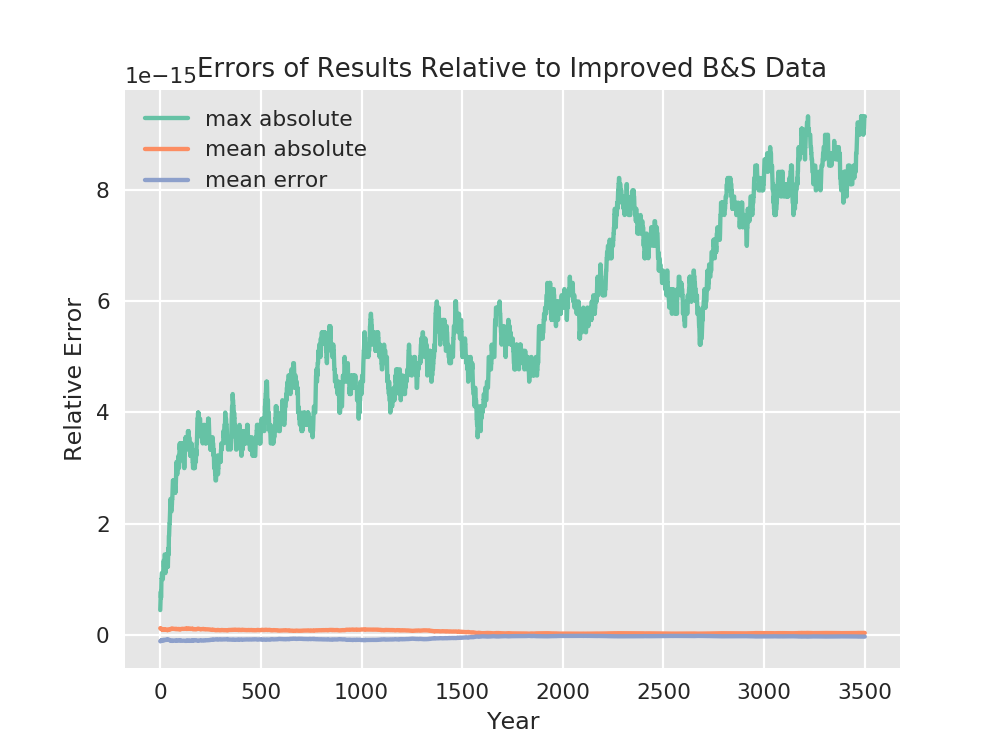

In [592]:
fig, ax = plot_errors(P, data['Psolution'])
ax.set_title('Errors of Results Relative to Improved B&S Data');

The reason that there is such a huge discrepancy is that Basener and Sanford have not sliced time thinly enough. They need to do many more iterations than they have done. And thus it is important to do the iterations rapdily, and to avoid loss of precision in doing them.

**Need to address this in context of theory**

It would have been easy for Basener and Sanford to obtain accurate results. All that they needed to do was to slice time thinner, and to run the computer longer. Basener's webpage would not be a crowd-pleaser, were it to take 2000 times longer than it presently does to generate results. But the results, unlike those that it presently generates, would stand a chance of serving some scientific purpose.

In [326]:
%%time
for year in t[1:]:
    P[year] = bs_annual_update(m, P[year-1], no_mutation, updates_per_year=10)

CPU times: user 16.5 s, sys: 0 ns, total: 16.5 s
Wall time: 16.5 s


In [327]:
maximum_absolute_relative_error(P, P[0] * np.exp(np.outer(t, factors.growth)))

0.8217532053170792

## Section 5.3: Gaussian

The standard deviation in Basener's code is 0.0005, which is just one-fourth of the value 0.002 reported in the article. Running the code at Basener's webpage gives nothing close to a match of [Figure 7](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig7_HTML.gif) in the article. So I have changed the standard deviation to 0.002 in [`BSalt.js`](../Code/BSalt.js).

The fitness interval is the same as in Section 5.2, but the greatest of the initial frequencies is about 0.08, not 0.032 as before. Our initial estimate of the "number of discrete population fitness values" is:

In [24]:
n_fitnesses(0.08)

249.0

This indicates that Basener and Sanford set the number to 200 for the shorter interval of growth factors (fitnesses), and that we should set it to 250 for the longer interval. Again, there is no mention of the different handling in the article. See [Replication of Section 5.3 (Gaussian mutations)](http://localhost:8888/notebooks/1_Replicate_Experiments/3_Gaussian_Mutations.ipynb) for verification that the results match those of Basener and Sanford.

In [614]:
%%time
n = 250
case = 'Gaussian'
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BSalt.js',
               output_path='../Basener_Sanford_Data/bs5_3alt.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_3alt')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_3alt.json
Done.
CPU times: user 201 ms, sys: 51 ms, total: 252 ms
Wall time: 2.01 s


We verify that the maximum of the initial frequencies is about 0.08.

In [615]:
with gzip.open('../Basener_Sanford_Data/bs5_3alt.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.07978845608028644

<IPython.core.display.Javascript object>


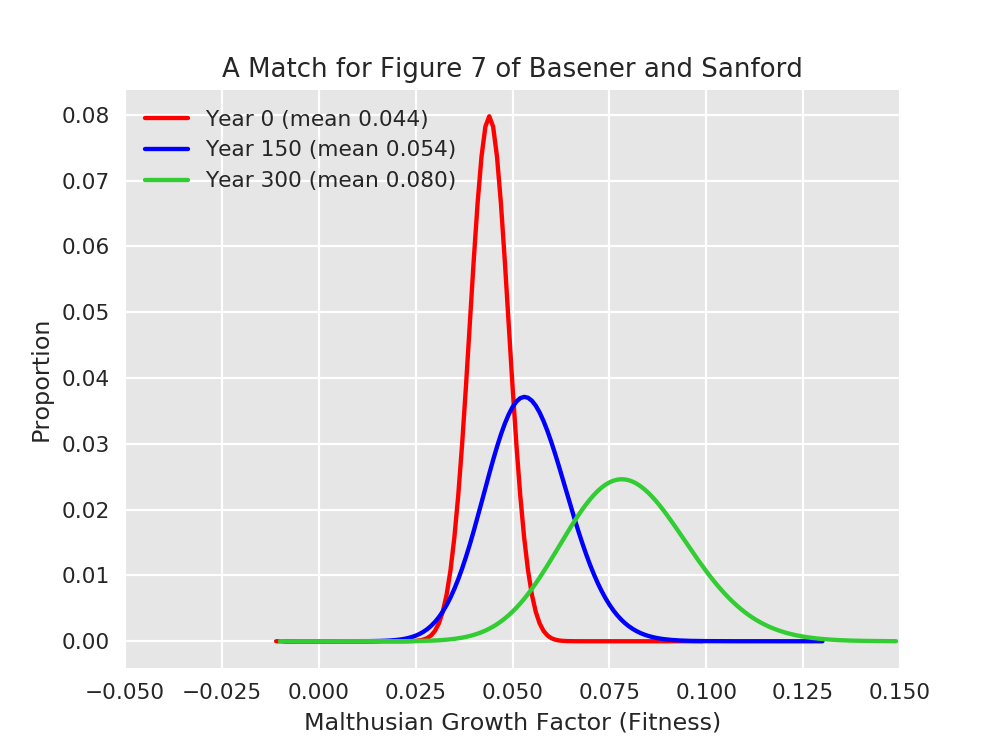

In [369]:
fig, ax = bs_plot(data['Psolution'], data['m'], 150)
ax.set_title('A Match for Figure 7 of Basener and Sanford')
ax.set_xlim(-0.05, 0.15);

**Figure 7 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig7_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig7_HTML.gif" /></a>


Click on the image for full resolution.

In [595]:
factors = Factors(250, exclude_max=True)
assert np.array_equal(factors.growth, data['m'])
assert np.array_equal(factors.birth, data['b'])
assert factors.delta == data['mDelta']

We obtain a good match for Basener's mutation probabilities with a single line of Python code.

In [596]:
mutations = factors.delta * stats.norm(0, 0.002).pdf(factors.effects)
np.max(relative_error(mutations, data['mutation_probs'], absolute=True)[mutations>0])

3.3306690738754696e-16

Before iterating the annual update, we verify that we also have a very good match for the initial frequency distribution:

In [597]:
t = np.arange(N_YEARS['Gaussian'] + 1)
P = np.empty((len(t), len(factors.growth)))
P[0] = bs_init(factors.growth, norm=fsum(data['Psolution'][0]))
np.max(relative_error(P[0], data['Psolution'][0], absolute=True)[P[0]>0])

2.220446049250313e-16

Now we iterate the annual update of frequencies.

In [598]:
for year in t[1:]:
    P[year] = bs_annual_update(factors, P[year-1], mutations, np.max, updates_per_year=1)

Next we check the mean of the absolute relative errors in the last year (restricted to nonzero frequencies).

In [599]:
np.mean(relative_error(P[-1], data['Psolution'][-1], absolute=True)[P[-1]>0])

5.5837279244741467e-14

<IPython.core.display.Javascript object>


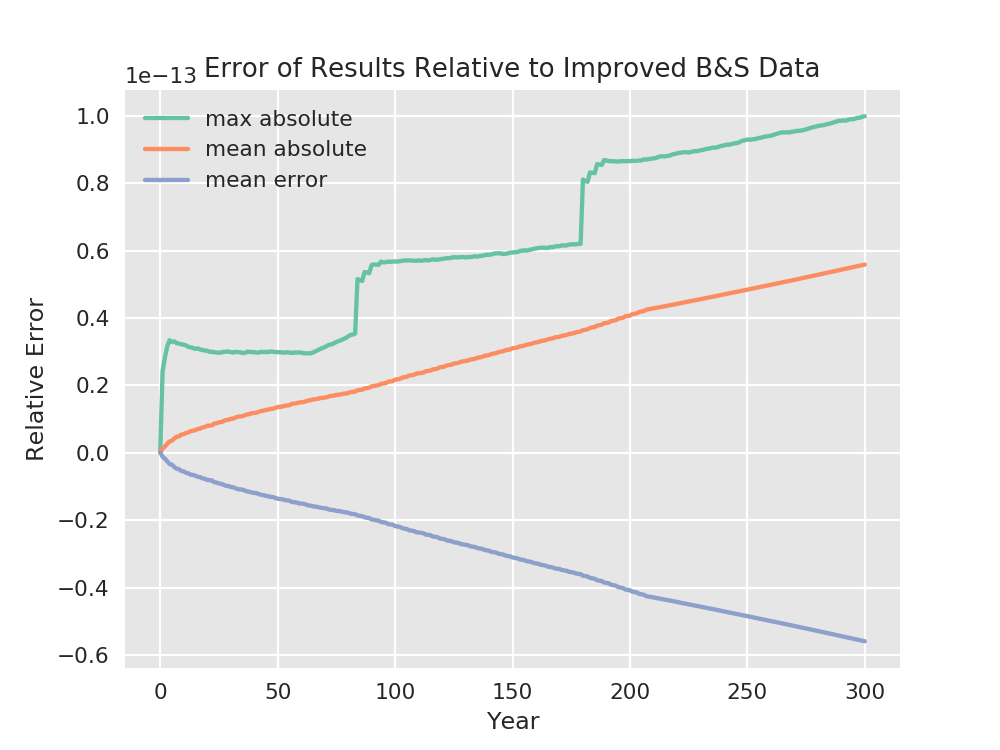

In [600]:
fig, ax = plot_errors(P, data['Psolution'])
ax.set_title('Error of Results Relative to Improved B&S Data');

Given the measures we have taken to match the inputs to the iteration, and to improve the precision of the JavaScript code for the iteration, it would seem that this is about as well as we can do. It bears mention that most of the `mutation` probabilities are zero, and that there is no error whatsoever in the processing of them.

In [402]:
np.sum(mutations == 0) / len(mutations)

0.6893787575150301

In [407]:
((fsum(mutations) / fsum(data['mutation_probs']))**300,
 fsum(P[-1]) / fsum(data['Psolution'][-1]))

(0.9999999999999667, 0.9999999999999535)

In [193]:
maximum_absolute_relative_error(P[0], data['Psolution'][0])

2.220446049250313e-16

In [194]:
maximum_absolute_relative_error(mutations, data['mutation_probs'])

4.440892098500626e-16

Let's have a look at how the mean and the maximum of the absolute relative error, restricted to nonzero frequencies, grow over time.

<IPython.core.display.Javascript object>


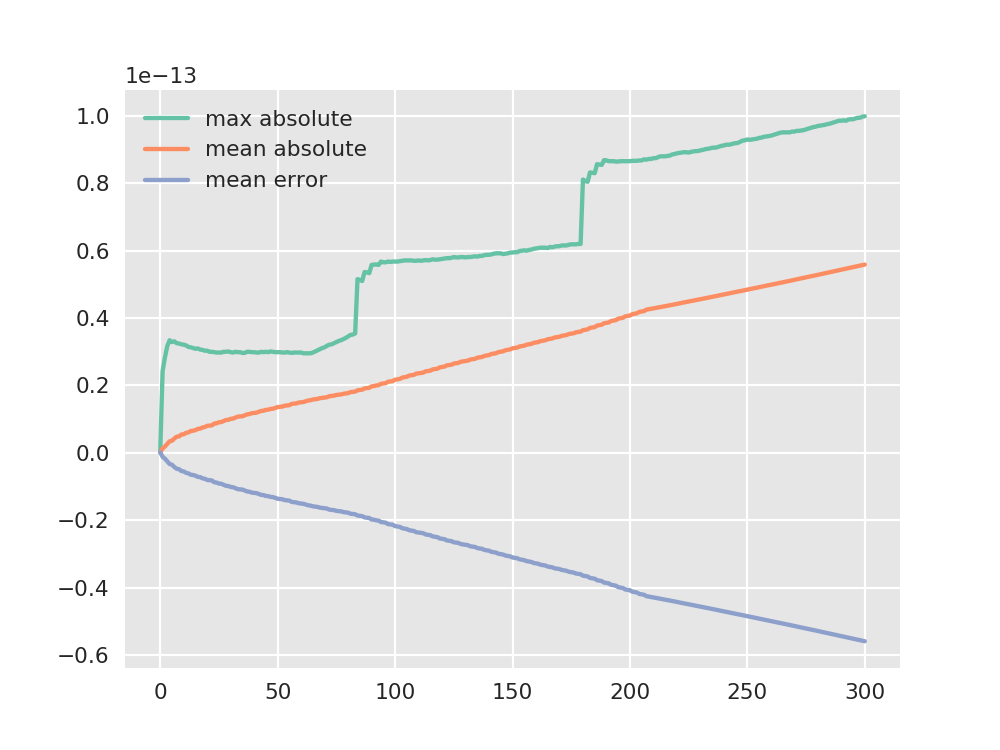

In [406]:
fig, ax = plt.subplots()
e = [np.max(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data['Psolution'])]
ax.plot(e, label='max absolute')
e = [np.mean(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data['Psolution'])]
ax.plot(e, label='mean absolute')
e = [np.mean(relative_error(p[d>0], d[d>0], absolute=False)) for p, d in zip(P, data['Psolution'])]
ax.plot(e, label='mean signed')
ax.legend()

Let's see how the picture changes when we operate on the initial frequencies and mutation probabilities output by `BSalt.js`.

In [408]:
P[0] = data['Psolution'][0]
mut = data['mutation_probs']
for year in t[1:]:
    P[year] = bs_annual_update(factors, P[year-1], mut, np.max)

<IPython.core.display.Javascript object>


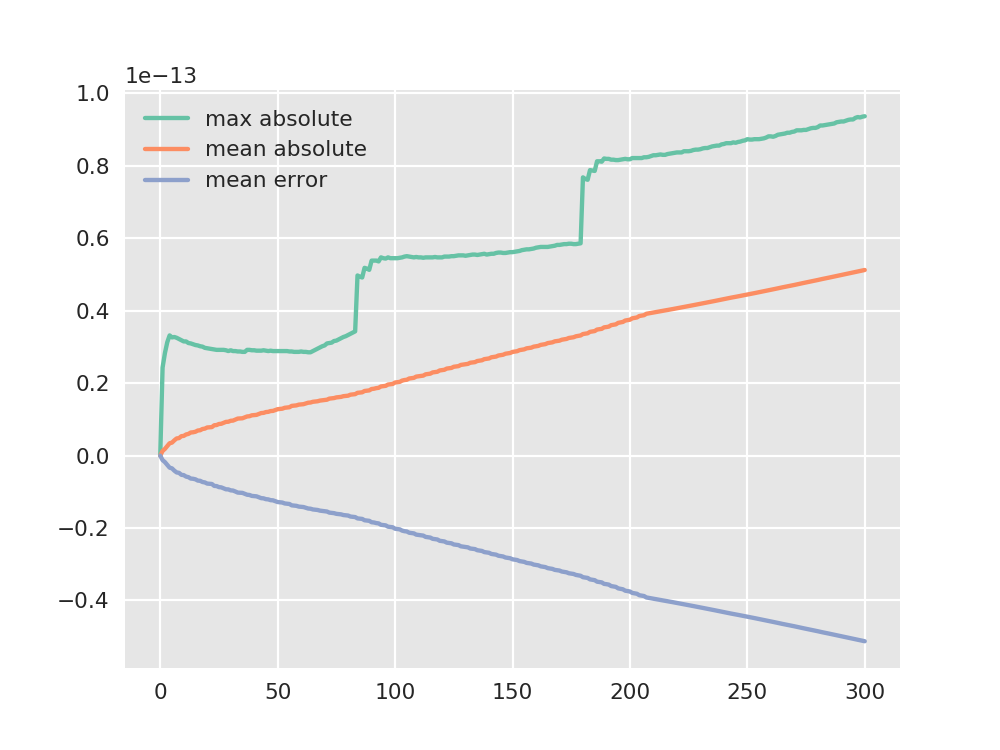

In [409]:
fig, ax = plt.subplots()
e = [np.max(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data['Psolution'])]
ax.plot(e, label='max absolute')
e = [np.mean(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data['Psolution'])]
ax.plot(e, label='mean absolute')
e = [np.mean(relative_error(p[d>0], d[d>0], absolute=False)) for p, d in zip(P, data['Psolution'])]
ax.plot(e, label='mean error')
ax.legend()

This leads to the question of how much the relative error can be reduced by scaling our frequencies to match Basener's frequencies in norm. In the final year, the relative error is reduce by a factor of 5.

In [413]:
s = fsum(data['Psolution'][-1]) / fsum(P[-1])
np.mean(relative_error(s * P[-1], data['Psolution'][-1])[P[-1]>0])

-9.5139174316472e-15

It would be nice to know whether there is some imprecision in my Python code, before using it to do large numbers of iterations. We will repeat the iteration with 100 digits of precision, using arbitrary-precision numbers, and compare the results to those plotted above.

**Require mpmath**

In [ ]:
# %load ../Code/bs_annual_update.py
def bs_annual_update(factors, frequencies, mutations,
                     threshold_norm=None, updates_per_year=1):
    birth_factors = factors.birth / updates_per_year
    death_factor = factors.death / updates_per_year
    f = np.array(frequencies)
    births = np.empty_like(f)
    for _ in range(updates_per_year):
        births[:] = np.convolve(birth_factors * f, mutations, mode='valid')
        f *= (1 - death_factor)
        f += births
    if not threshold_norm is None:
        f[f <= 1e-9 * threshold_norm(f)] = 0
    return f

In [520]:
%%time
from mpmath import mp
mp.dps = 32
p = np.empty_like(P, dtype=object)
p[0] = [mp.mpf(x) for x in data['Psolution'][0]]
mut = np.array([mp.mpf(x) for x in data['mutation_probs']])
b = np.array([mp.mpf(x) for x in data['b']])
survival_rate = mp.mpf(1) - mp.mpf(0.1)
births = np.empty_like(p[0])
for year in t[1:]:
    births[:] = np.convolve(b * p[year-1], mut, mode='valid')
    p[year] = survival_rate * p[year-1] + births
    threshold = 1e-9 * np.max(p[year])
    p[year][p[year] <= threshold] = mp.mpf(0)

CPU times: user 3min 37s, sys: 64 ms, total: 3min 37s
Wall time: 3min 38s


<IPython.core.display.Javascript object>


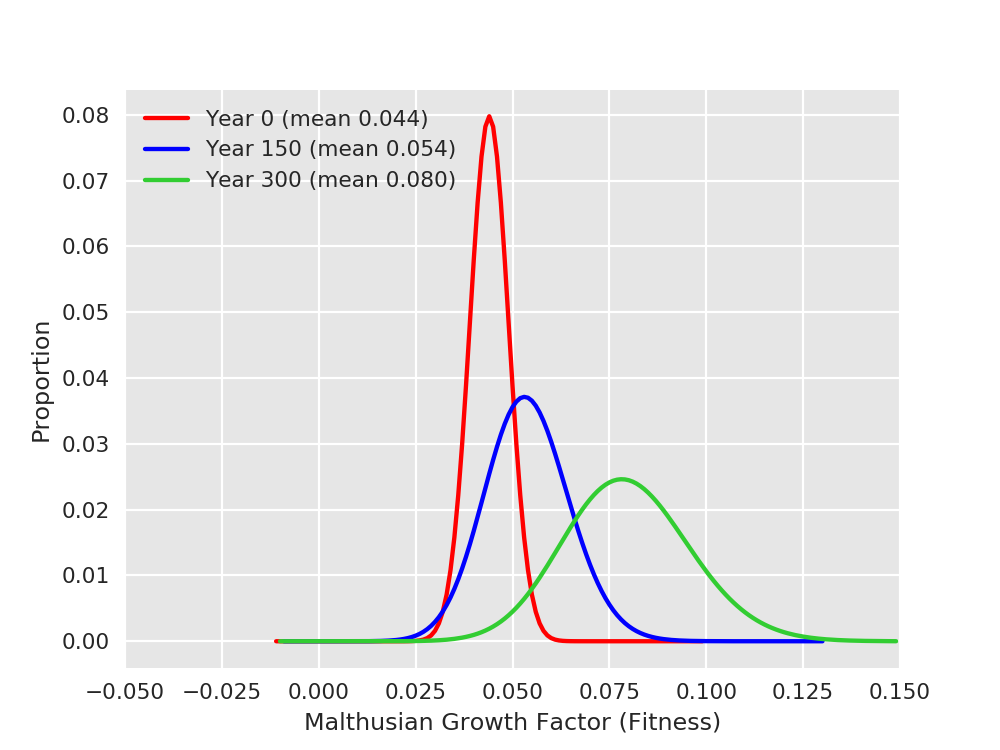

(-0.05, 0.15)

In [452]:
fig, ax = bs_plot(p, factors.growth, 150)
ax.set_xlim(-0.05, 0.15)

In [447]:
float(np.mean(relative_error(p[-1], data['Psolution'][-1], absolute=False)[p[-1]>0]))

-5.943554629199722e-14

In [449]:
float(np.mean(relative_error(p[-1], P[-1], absolute=False)[p[-1]>0]))

-7.991060950840016e-15

<IPython.core.display.Javascript object>


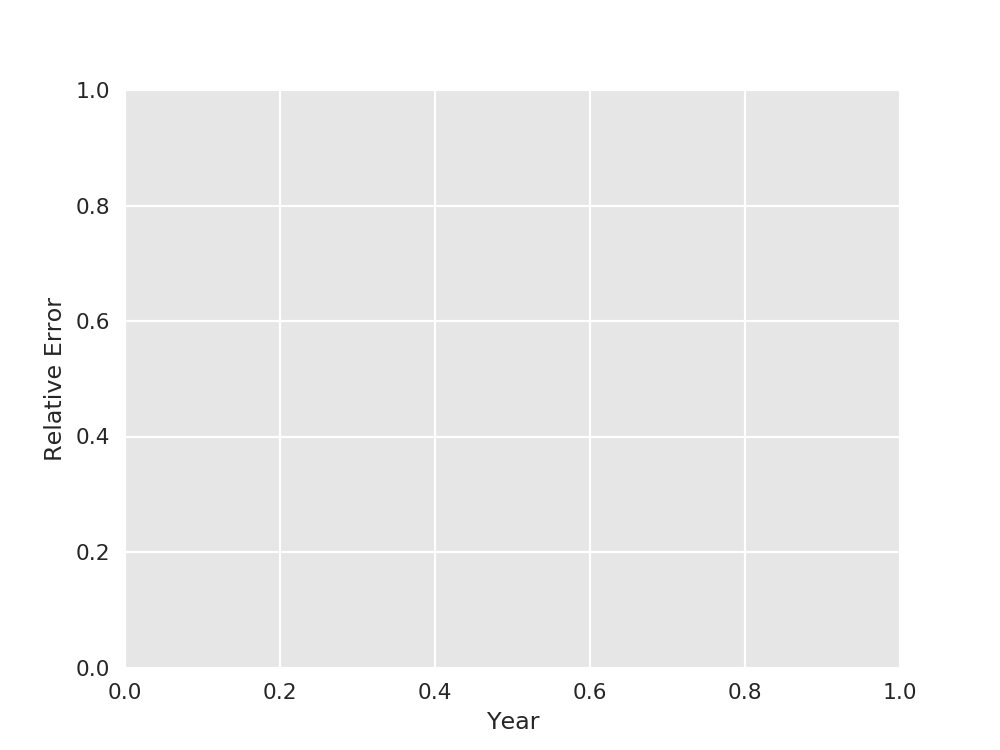

IndexError: boolean index did not match indexed array along dimension 0; dimension is 250 but corresponding boolean dimension is 625

In [654]:
fig, ax = plot_errors(p, data['Psolution'])
ax.set_title('Deviation with High Precision Operations');

The difference increases more, not less, rapidly when the Python calculation (using Basener's data) is high in precision. This indicates either that there is loss of precision in Basener's code that I have not managed to account for, or that there is an anomaly of some sort in the Numpy `convolve` function. What we will do next, because it does not require much code, and because it is fun, is to mimic Basener's array multiplication (which I simplified above), and ensure that we get the same result as with convolution. Basener's array `MP` contains the products of birth factors and mutation probabilities.
```javascript
var MP = new Array(numIncrements);   

for (i = 0; i < numIncrements; i++) {
    MP[i] = new Array(numIncrements);
    for (j = 0; j < numIncrements; j++) {
        MP[i][j] = b[j] * mutationProb(m[i] - m[j], mDelta, mt);
    }
}
```
The general element `MP[i][j]` is, loosely, the rate of birth of type `i` offspring to parents of type `j`. An odd thing that Basener does here is to take the differences `m[i] - m[j]` of growth factors. Due to the fact that the growth factors do not have exact binary representations, the differences are not identical in magnitude to birth factors, as they ought to be. We instead take differences `i - j` of indices, and translate them into indices of the vector of mutation probabilities.

In [541]:
def vector_updates(initial_freqs, birth_factors, death_factor, mutations, n_years, threshold_norm=np.max):
    zero = birth_factors[0]
    f = np.repeat([initial_freqs], n_years+1, axis=0)
    for year in range(1, len(f)):
        f[year] = np.convolve(birth_factors * f[year-1], mutations, mode='valid') 
        f[year] += (1 - death_factor) * f[year-1]
        relatively_small = f[year] <= 1e-9 * threshold_norm(f[year])
        f[year][relatively_small] = zero  
    return f

In [1]:
class Population(object):
    def __init__(self, initial_freqs, mutations, updates_per_year=1,
                       norm=np.max, lossy=True):
        self.f = np.array(initial_freqs)
        self.births = np.empty_like(initial_freqs)
        self.annual_factors = initial_freqs.factors
        self.death_factor = self.annual_factors.death / updates_per_year
        self.updates_per_year = updates_per_year
        self.mutations = mutations
        n = len(initial_freqs)
        birth_factors = self.annual_factors.birth / updates_per_year
        self.birthing = np.repeat([birth_factors], n, axis=0)
        self.birthing *= mutations.convolution_matrix(lossy)
        self.norm = norm
        self.zero = initial_freqs[0] * 0
    
    def annual_update(self):
        for _ in range(self.updates_per_year):
            np.dot(self.birthing, self.f, out=self.births)
            self.f *= 1 - self.death_factor
            self.f += self.births
        if not self.norm is None:
            relatively_small = self.f <= 1e-9 * self.norm(self.f)
            self.f[relatively_small] = self.zero  
        return f

    def growth_factors(self, effective=False):
        if effective:
            g = np.array([fsum(col) for col in self.birthing.T])
            g += 1 - self.factors.death
            return np.log(g) * self.updates_per_year
        return self.annual_factors.growth
    
def matrix_updates(initial_freqs, birth_factors, death_factor, mutations, n_years, threshold_norm=np.max):
    zero = birth_factors[0]
    n = len(initial_freqs)
    f = np.repeat([initial_freqs], n_years+1, axis=0)
    birthing = np.repeat([birth_factors], n, axis=0)
    birthing *= [mutations[i:i+n][::-1] for i in range(n)]
    for year in range(1, len(f)):
        f[year] = np.dot(birthing, f[year-1]) 
        f[year] += (1 - death_factor) * f[year-1]
        relatively_small = f[year] <= 1e-9 * threshold_norm(f[year])
        f[year][relatively_small] = zero  
    return f

NameError: name 'np' is not defined

In [552]:
def precise(function, initial_freqs, birth_factors, mutations, n_years, threshold_norm=np.max):
    mutations = np.array([mp.mpf(x) for x in mutations])
    birth_factors = np.array([mp.mpf(x) for x in birth_factors])
    initial_freqs = np.array([mp.mpf(x) for x in initial_freqs])
    death_factor = mp.mpf(DEATH_FACTOR)
    return function(initial_freqs, birth_factors, death_factor, mutations, n_years, threshold_norm)

In [542]:
m_freqs = matrix_updates(data['Psolution'][0], data['b'], DEATH_FACTOR, data['mutation_probs'], 300)
v_freqs = vector_updates(data['Psolution'][0], data['b'], DEATH_FACTOR, data['mutation_probs'], 300)

There's essentially no difference in the match of the results for the two algorithms to the results of Basener's code.

In [549]:
(np.mean(relative_error(m_freqs[-1], data['Psolution'][-1], absolute=True)[m_freqs[-1]>0]),
 np.mean(relative_error(v_freqs[-1], data['Psolution'][-1], absolute=True)[m_freqs[-1]>0]))

(5.129160984829184e-14, 5.125552759999152e-14)

The two algorithms do some operations in different order, and thus differ slightly in the results that they generate.

In [550]:
(np.mean(relative_error(m_freqs[-1], v_freqs[-1], absolute=True)[m_freqs[-1]>0]),
 np.mean(relative_error(v_freqs[-1], m_freqs[-1], absolute=True)[m_freqs[-1]>0]))

(2.9906632725840155e-16, 2.921274333544943e-16)

Now we iterate the annual update of frequencies with 100 digits of precision, and check to see how the results differ from those we generated with 64-bit doubles (53-bit significands).

In [553]:
%%time
mp.dps = 100
pm_freqs = precise(matrix_updates, data['Psolution'][0], data['b'], data['mutation_probs'], 300)

CPU times: user 3min 40s, sys: 83 ms, total: 3min 40s
Wall time: 3min 40s


In [554]:
%%time
mp.dps = 100
pv_freqs = precise(vector_updates, data['Psolution'][0], data['b'], data['mutation_probs'], 300)

CPU times: user 3min 42s, sys: 79 ms, total: 3min 42s
Wall time: 3min 42s


Cross checking the high-precision results in the last year, we find that they in fact are identical in 100 significant digits.

In [557]:
(np.max(relative_error(pm_freqs[-1], pv_freqs[-1], absolute=True)[m_freqs[-1]>0]),
 np.max(relative_error(pv_freqs[-1], pm_freqs[-1], absolute=True)[m_freqs[-1]>0]))

(mpf('7.143671195514218638848647176908380996574437467642491632594536520172703974417113722971550136626075185307e-101'),
 mpf('7.143671195514218638848647176908380996574437467642491632594536520172703974417113722971550136626075185307e-101'))

The frequencies are slightly smaller for the higher-precision calculations than for the lower-precision calculations. (Note that `absolute` is set to `False` in the following cells.)

In [564]:
(np.mean(relative_error(m_freqs[-1], pm_freqs[-1], absolute=False)[m_freqs[-1]>0]),
 np.mean(relative_error(v_freqs[-1], pv_freqs[-1], absolute=False)[v_freqs[-1]>0]))

(8.141788353680215e-15, 8.180913651906813e-15)

Thus increasing the precision makes our results *more*, not less, different from Basener's results.

In [567]:
(float(np.mean(relative_error(m_freqs[-1], data['Psolution'][-1], absolute=False)[pm_freqs[-1]>0])),
 float(np.mean(relative_error(v_freqs[-1], data['Psolution'][-1], absolute=False)[pv_freqs[-1]>0])))

(-5.129160984829184e-14, -5.125552759999152e-14)

In [568]:
(float(np.mean(relative_error(pm_freqs[-1], data['Psolution'][-1], absolute=False)[pm_freqs[-1]>0])),
 float(np.mean(relative_error(pv_freqs[-1], data['Psolution'][-1], absolute=False)[pv_freqs[-1]>0])))

(-5.943554629199722e-14, -5.943554629199722e-14)

In a plot of the errors of our low-precision results to the high-precision results, there is nothing like the artifacts that we saw for the output of Basener's code.

<IPython.core.display.Javascript object>


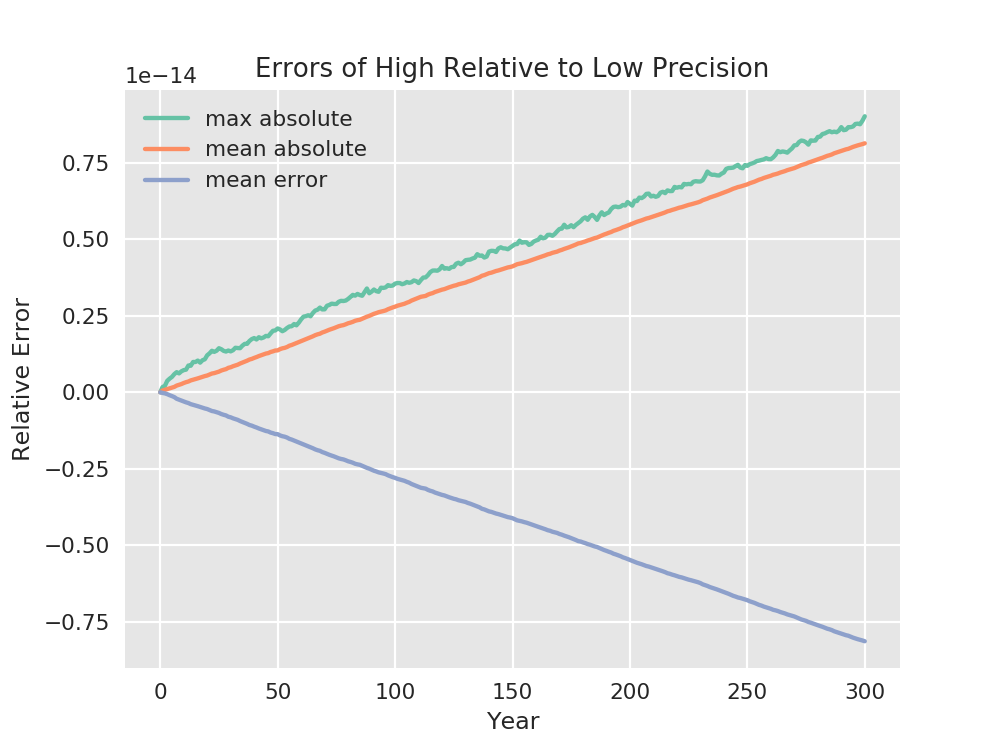

In [574]:
fig, ax = plot_errors(pm_freqs, m_freqs)
ax.set_title('Errors of High Relative to Low Precision');

<IPython.core.display.Javascript object>


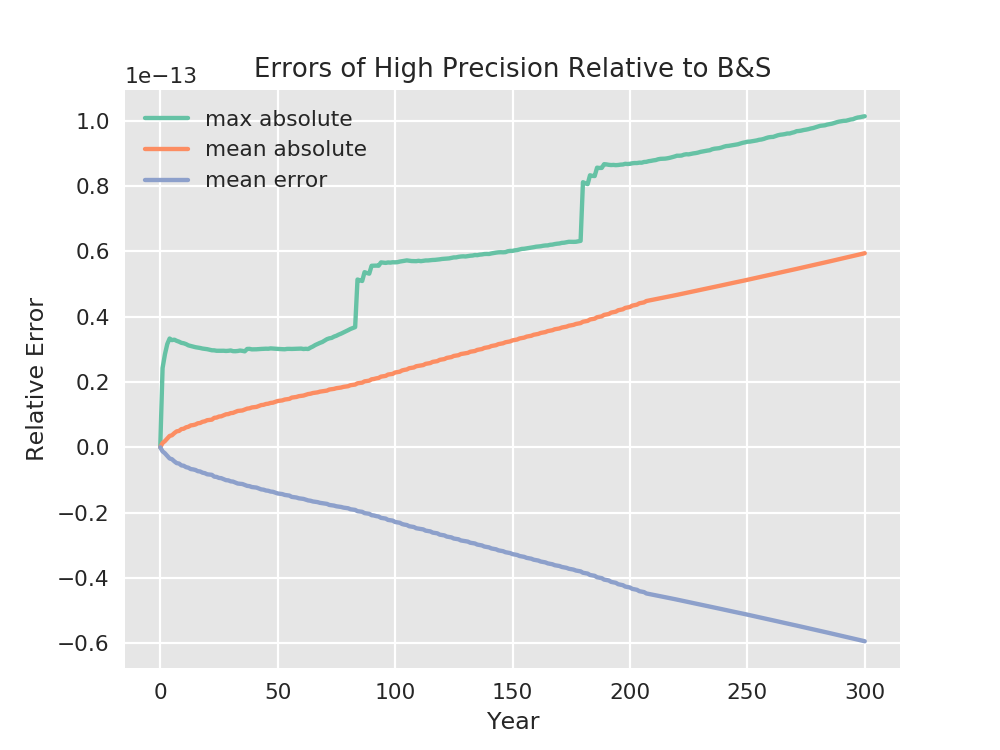

In [575]:
fig, ax = plot_errors(pm_freqs, data['Psolution'])
ax.set_title('Errors of High Precision Relative to B&S');

Run `BS.js` and see if the artifacts are due to `jStat.dot` in `BSalt.js`.

In [683]:
%%time
n = 250
case = 'Gaussian'
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_3.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_3')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_3.json
Done.
CPU times: user 352 ms, sys: 64 ms, total: 416 ms
Wall time: 2.94 s


In [684]:
with gzip.open('../Basener_Sanford_Data/bs5_3.pickled.gz') as f:
    original = pickle.load(f)
np.max(original['Psolution'][0])

0.07978845608028644

<IPython.core.display.Javascript object>


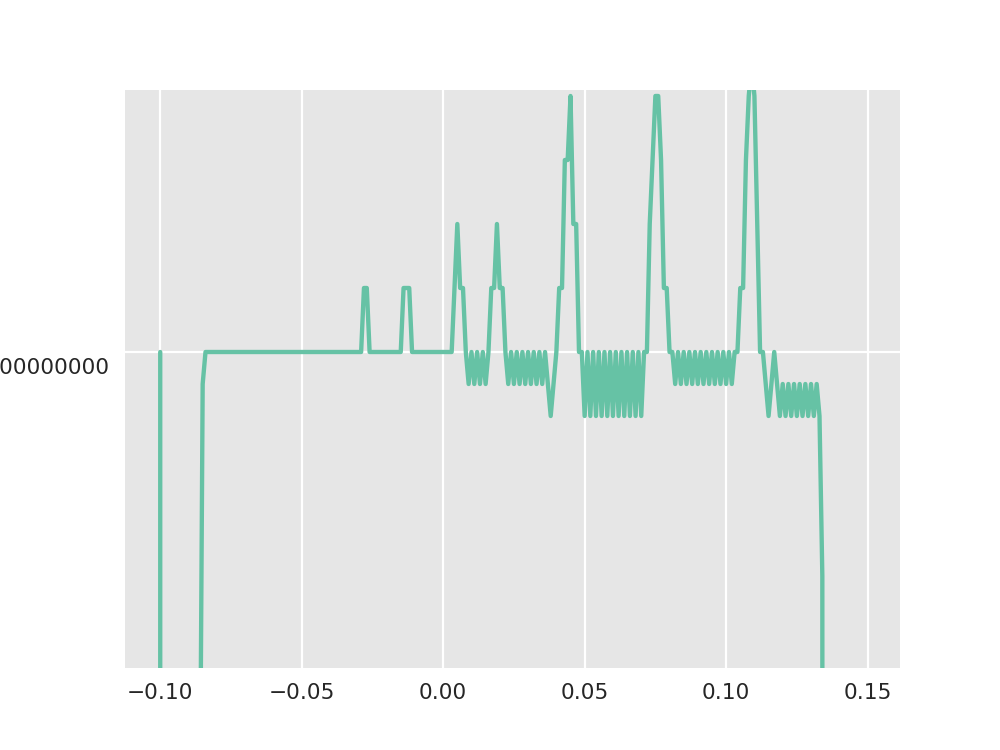

(0.999999999999999, 1.000000000000001)

In [722]:
plt.close('all')
factors = Factors(250, exclude_max=True)
MP = original['MP']
b_effect = np.array([fsum(col) for col in MP.T])
m_effect = b_effect + (1 - DEATH_FACTOR) * 1
fig, ax = plt.subplots()
ax.plot(factors.growth, m_effect - factors.growth)
ax.set_ylim(1-1e-15, 1+1e-15)

In [741]:
mpf_total = mp.mpf(1)
total = 1
for x in MP[125]:
    total += x
    mpf_total += x
total -= 1
mpf_total -= 1
total - fsum(MP[125]) 

3.0531133177191805e-16

<IPython.core.display.Javascript object>


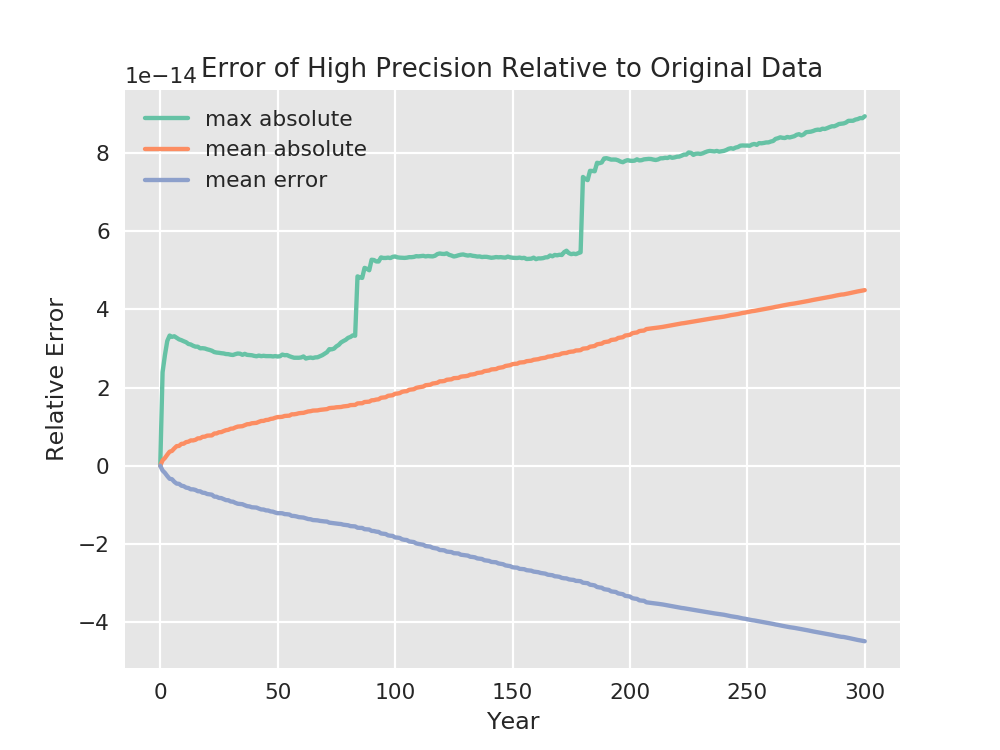

Text(0.5,1,'Error of High Precision Relative to Original Data')

In [618]:
fig, ax = plot_errors(pm_freqs, original['Psolution'])
ax.set_title('Error of High Precision Relative to Original Data');

<IPython.core.display.Javascript object>


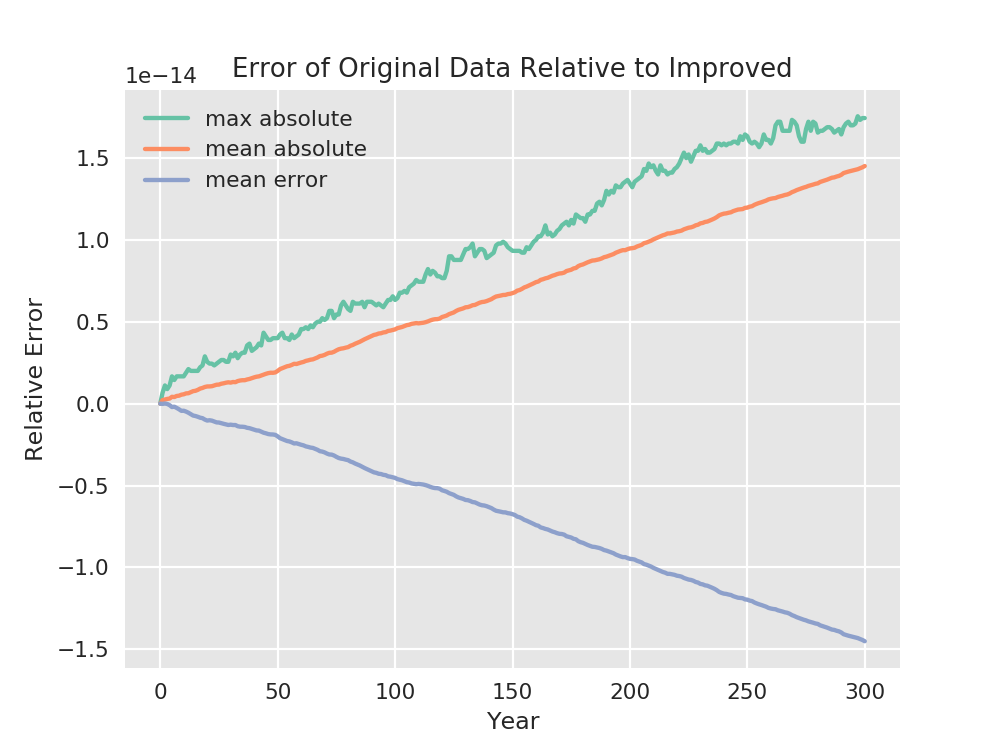

Text(0.5,1,'Error of Original Data Relative to Improved')

In [619]:
fig, ax = plot_errors(original['Psolution'], data['Psolution'])
ax.set_title('Error of Original Data Relative to Improved')

## Section 5.4: Gamma

Only in Section 5.4 does the interval of fitness values match that of Basener's webpage. The maximum of the initial frequencies in [Figure 10](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif) is about 0.04. Our initial estimate of the number of points in the fitness interval is:

In [8]:
n_fitnesses(0.04)

499.0

Basener and Sanford report the number 500, and it appears that we should believe them in this case. Running the code at Basener's webpage with the "number of discrete population fitness values" set to 500, the resulting figures are good matches for the figures in Section 5.4. However, when we attempt a detailed comparison of numeric data to the figures, we discover that the figures are not consistent with each other.

In [249]:
n = 500
case = 'Gamma'
c = bs_command(percentage_of_mutations_that_are_beneficial=0.001,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_4.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_4')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_4.json
Done.


We verify that the maximum of the initial frequencies is about 0.04, as in [Figure 10](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif) of the article.

In [250]:
with gzip.open('../Basener_Sanford_Data/bs5_4.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.03989422804014321

<IPython.core.display.Javascript object>


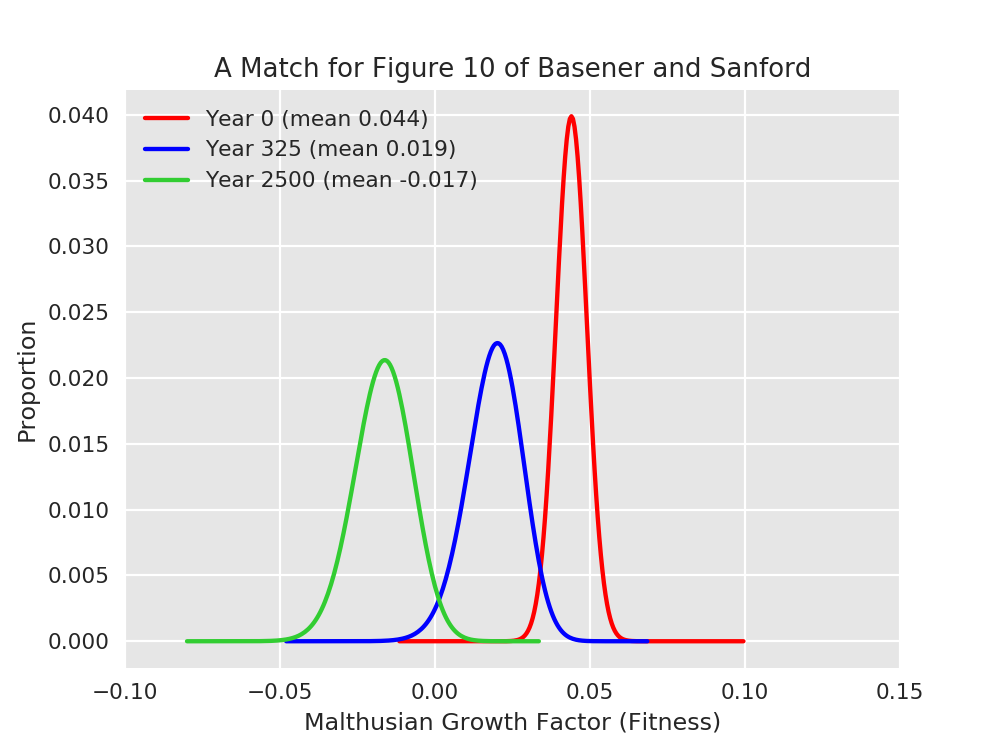

In [251]:
fig, ax = bs_plot(data['Psolution'], data['m'], 325)
ax.set_title('A Match for Figure 10 of Basener and Sanford')
ax.set_xlim(-0.10, 0.15);

**Figure 10 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif" /></a>


Click on the image for full resolution.

In [203]:
factors = Factors(500, exclude_max=True)
assert np.array_equal(factors.growth, data['m'])
assert np.array_equal(factors.birth, data['b'])
assert factors.delta == data['mDelta']

Basener's JavaScript for the `Gamma` case features an egregious gimmick, which the article does not report. The probabilty that mutation has no effect on fitness is set arbitrarily to the probability that mutation has a minimally deleterious effect on fitness. The gimmick not only reduces the probability of neutral mutation greatly, but also makes the birth rates much lower than Basener and Sanford report them to be. We'll establish elsewhere in this binder that Basener and Sanford needed both the unreported gimmick and the dubious zeroing of relatively small frequencies to obtain the "crashing population" that they report in Section 5.4. Eliminate one or the other of the devices, and the population grows, rather than shrinks, over the long term.

```javascript
function mutationProb(mDiff, mDelta, mt) {
    // mDiff is the difference in fitness of the offspring from the parent
    // mDelta is the spacing of discrete fitnesses in the fitness interval
    // mt is the "mutation distribution type"
    // snip
    if (mt == "Gamma") {
        if (mDiff == 0)      // If difference in fitness is 0,
            mDiff = -mDelta; // change it to the minimum negative difference.
        // Basener considered making the parameters different for the upper
        // and lower tails.
        var sBarBeneficial = 0.001;
        var sBarDeleterious = 0.001;
        var aBeneficial = 0.5;
        var aDeleterious = 0.5;
        var bBeneficial = aBeneficial / sBarBeneficial;
        var bDeleterious = aDeleterious / sBarDeleterious;
        if (mDiff > 0)
            // Simple scaling by PctBeneficial tacitly assumes that the mass
            // assigned to positive effects by the Gamma distribution is 1.
            f = (PctBeneficial) * Math.pow(bBeneficial, aBeneficial)
                                * Math.pow(mDiff, aBeneficial - 1) 
                                * Math.exp(-bBeneficial * mDiff) 
                                / Gamma(aBeneficial); // Basener's implementation
        if (mDiff < 0) 
            // Simple scaling by 1 - PctBeneficial tacitly assumes that the mass
            // assigned to negative mutation effects by the reflected Gamma 
            // distribution is 1.
            f = (1 - PctBeneficial) * Math.pow(bDeleterious, aDeleterious)
                                    * Math.pow(Math.abs(mDiff), aDeleterious - 1)
                                    * Math.exp(-bDeleterious * Math.abs(mDiff))
                                    / Gamma(aDeleterious);
        f = f * mDelta; // multiply probability density by length of subinterval
    }
    // snip
    return f;                                      
}
```

In essence, Basener is pretending that all mutations are either beneficial or deleterious. His calculation would be approximately correct if the probability of zero effect were close to zero. The probability of zero effect is, however, nowhere close to zero. One of the consequences of Basener's false assumption of the contrary is that the probabilities sum to considerably less than 1:

In [230]:
fsum(data['mutation_probs'])

0.8219477435366035

As an immediate consequence, the birth rates are only 82 percent as great as stated in the article. Furthermore, the probability that a mutation is beneficial in effect is about 40 percent less than claimed:

In [231]:
fsum(data['mutation_probs'][factors.effects > 0])

0.0006024717944449918

Now we define a Python function that, depending on the setting of the `gimmick` parameter, either reimplements the gimmick that got Basener and Sanford the kind of results that they wanted to report, or calculates the reflected, reweighted Gamma distribution correctly.

In [315]:
# %load ../Code/bs_gamma.py
def bs_gamma(factors, alpha=0.5, beta=0.5/0.001, percent_beneficial=0.001, gimmick=True):
    effects = factors.effects
    p = stats.gamma(alpha, scale=1/beta).pdf(np.abs(effects))
    if gimmick:
        p[effects == 0] = p[effects < 0][-1]
        p[effects > 0] *= percent_beneficial
        p[effects <= 0] *= 1 - percent_beneficial
        p *= factors.delta
    else:
        p[effects != 0] *= factors.delta
        p[effects == 0] = 2 - fsum(p[effects != 0])
        p[effects > 0] *= percent_beneficial / fsum(p[effects > 0])
        p[effects <= 0] *= (1 - percent_beneficial) / fsum(p[effects <= 0])
    return p

Without the gimmick, the distribution is normalized:

In [301]:
(fsum(bs_gamma(factors, gimmick=True)),
 fsum(bs_gamma(factors, gimmick=False)))

(0.8219477435273, 1.0)

The results of our reimplementation of the gimmick do not match the results of Basener's implementation fabulously well, though the probabilities are identical in 11 significant digits.

In [271]:
mutations = bs_gamma(factors, gimmick=True)
maximum_absolute_relative_error(mutations, data['mutation_probs'])

5.928590951498336e-14

A loss of 5 significant digits of accuracy in such a straightforward calculation is something that needs explaining. The problem is again that Basener has neglected numerical precision&nbsp;&mdash; a crucial consideration in iterative update of the frequencies. (Keep it in mind that Basener should have done many more iterations than he actually did.) It is easy to see, in his calculation of the Gamma density function, that he multiplies exponentiated quantities when he should have summed quantities and then exponentiated. In `BSalt.js`, I have replaced Basener's calculation of the Gamma density with a call to `jStat.gamma.pdf()`.

**I do not know whether installation of the jStat package will pose a problem on Jupyter servers. On my local host, I installed it with the command `npm install jStat`.**

In [318]:
############# THIS REQUIRES jStat INSTALLATION #################
n = 500
case = 'Gamma'
c = bs_command(percentage_of_mutations_that_are_beneficial=0.001,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BSalt.js',
               output_path='../Basener_Sanford_Data/bs5_4alt.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_4alt')

Initializing.
/home/user/83bce9aa2578a9f249badfc0e917aca3d5610e2e/Downloads/NewNotebooks/BS/Code/BSalt.js:98
        f = jStat.gamma.pdf(Math.abs(mDiff), alpha, 1 / beta);
                  ^

TypeError: Cannot read property 'gamma' of undefined
    at mutationProb (/home/user/83bce9aa2578a9f249badfc0e917aca3d5610e2e/Downloads/NewNotebooks/BS/Code/BSalt.js:98:19)
    at runSimulation (/home/user/83bce9aa2578a9f249badfc0e917aca3d5610e2e/Downloads/NewNotebooks/BS/Code/BSalt.js:192:31)
    at Object.<anonymous> (/home/user/83bce9aa2578a9f249badfc0e917aca3d5610e2e/Downloads/NewNotebooks/BS/Code/BSalt.js:274:1)
    at Module._compile (module.js:635:30)
    at Object.Module._extensions..js (module.js:646:10)
    at Module.load (module.js:554:32)
    at tryModuleLoad (module.js:497:12)
    at Function.Module._load (module.js:489:3)
    at Function.Module.runMain (module.js:676:10)
    at startup (bootstrap_node.js:187:16)


Now we get a much better match of probabilities.

In [303]:
with gzip.open('../Basener_Sanford_Data/bs5_4alt.pickled.gz') as f:
    data = pickle.load(f)
np.mean(relative_error(mutations, data['mutation_probs'], absolute=True))

4.730794779385229e-14

In [304]:
mut = mutations * fsum(data['mutation_probs']) / fsum(mutations)
np.mean(relative_error(mut, data['mutation_probs'], absolute=True))

5.263946324764281e-15

In [311]:
t = np.arange(N_YEARS['Gamma'] + 1)
P = np.empty((len(t), len(factors.growth)))
P[0] = bs_init(factors.growth)
for year in t[1:]:
    P[year] = bs_annual_update(factors, P[year-1], mutations, np.max, updates_per_year=1)

In [313]:
np.max(relative_error(P[-1], data['Psolution'][-1], absolute=True))

8.079092950197264e-12

Figure 10 also reports, in text, that the mean fitness in year 325 is 0.019.

In [29]:
data['meanFitness'][325]

0.019106711033872802

The maximum of the proportions in year 325 matches the maximum of the curve for that year in Figure 10.

In [25]:
np.max(data['Psolution'][325] / fsum(data['Psolution'][325]))

0.022657951328700143

In [26]:
len(data['meanFitness'])

2501

Basener and Sanford indicate in the text that the mean fitness decreases to about -0.014 in year 2500. Also, we observe in [Figure 12](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig12_HTML.gif) that the variance in fitness in the final year is roughly 0.000086.

In [21]:
data['meanFitness'][-1], data['varianceFitness'][-1]

(-0.016821601704253245, 8.738476329018091e-05)

In [225]:
initial_freqs = BS_InitialFrequencies(N_TYPES['Gamma'])
mutations = GammaEffects(N_TYPES['Gamma'], gimmick=True, normed=False, approximate=True, percent_beneficial=0.001)
# mutations.p *= fsum(data['mutation_probs']) / fsum(mutations[1:-1])
print(fsum(data['mutation_probs']) / fsum(mutations[:]))
ev = Evolution(BS_Population(initial_freqs, mutations, threshold_norm=np.max, endpoint=False), N_YEARS['Gamma'])
maximum_absolute_relative_error(ev[:, :-1], data['Psolution'])
#maximum_absolute_relative_error(mutations[1:-1], data['mutation_probs'])

NameError: name 'growth_factors' is not defined

In [84]:
maximum_absolute_relative_error(mutations[1:-1], data['mutation_probs'])

1.1323830761966747e-11

0.0

## Clean up

The zipped pickles of the Python dictionaries containing the results are about one-third the size of the JSON outputs of `BS.js`. We keep the former, and dispose of the latter.

In [10]:
!ls -l ../Basener_Sanford_Data/bs5_*
!rm ../Basener_Sanford_Data/bs5_*.json

-rw-r--r--. 1 chronos chronos 23519108 Apr 30 05:49 ../Basener_Sanford_Data/bs5_2actual.json
-rw-r--r--. 1 chronos chronos  7831969 Apr 30 05:49 ../Basener_Sanford_Data/bs5_2actual.pickled.gz
-rw-r--r--. 1 chronos chronos 23545586 Apr 30 05:48 ../Basener_Sanford_Data/bs5_2desired.json
-rw-r--r--. 1 chronos chronos  7725825 Apr 30 05:48 ../Basener_Sanford_Data/bs5_2desired.pickled.gz
-rw-r--r--. 1 chronos chronos   890809 Apr 30 05:49 ../Basener_Sanford_Data/bs5_3.json
-rw-r--r--. 1 chronos chronos   317409 Apr 30 05:49 ../Basener_Sanford_Data/bs5_3.pickled.gz
-rw-r--r--. 1 chronos chronos 14478397 Apr 30 05:49 ../Basener_Sanford_Data/bs5_4.json
-rw-r--r--. 1 chronos chronos  4600296 Apr 30 05:49 ../Basener_Sanford_Data/bs5_4.pickled.gz


## Listing of files

In [11]:
!ls -l ../Basener_Sanford_Data/

total 20024
-rw-r--r--. 1 chronos chronos 7831969 Apr 30 05:49 bs5_2actual.pickled.gz
-rw-r--r--. 1 chronos chronos 7725825 Apr 30 05:48 bs5_2desired.pickled.gz
-rw-r--r--. 1 chronos chronos  317409 Apr 30 05:49 bs5_3.pickled.gz
-rw-r--r--. 1 chronos chronos 4600296 Apr 30 05:49 bs5_4.pickled.gz


## Implementation details

To make Basener's script usable from the command line, I have

1. deleted the part of Basener's script that generates graphics on the webpage,
2. replaced code that gets parameter settings from entries on the webpage with code that gets the settings from command-line arguments, and
3. added code to output the values of variables at the end of Basener's computation.

I have also defined, at the end of Basener's `runSimulation` function, an array `mutation_probs`, and have stored in it the values of Basener's `mutationProbs()` function for each of the possible changes in fitness due to mutation:

```javascript
var mutation_probs = new Array(2 * b.length - 1);
var zero_index = b.length - 1;

for (var i = 0; i < b.length; i++) {
    mutation_probs[zero_index - i] = mutationProb(-b[i], mDelta, mt);
    mutation_probs[zero_index + i] = mutationProb(b[i], mDelta, mt);
}
```

The array entry `b[i]` contains the Malthusian birth factor for the $i$-th type of organism. Basener does not pass elements of `b` to `mutationProb`, but instead differences `m[i] - m[j]` of Malthusian growth factors. The factors do not have exact binary representations, so `m[i] - m[j]` is generally not identical in magnitude to `b[abs(i - j)]` in practice as it is in theory.